# How to train your potential

## Phase 1: Seed Data & Initial Training

In [25]:
import numpy as np
from ase.build import bulk
from ase.calculators.lj import LennardJones
from ase.md.langevin import Langevin
from ase.io import read, write, Trajectory
from ase import units, Atoms

import matplotlib.pyplot as plt

# 1. Setup the Argon Box (108 atoms)
# 3x3x3 supercell of an FCC unit cell
atoms = bulk(
    'Ar',
    crystalstructure='fcc',
    a=5.00, 
    cubic=True).repeat((3, 3, 3))

# 2. Attach the "Ground Truth" Lennard-Jones Calculator
# Parameters for Argon: epsilon in eV, sigma in Angstroms
truth_calc = LennardJones(epsilon=0.0103, sigma=3.40)
atoms.calc = truth_calc

# 3. Setup Molecular Dynamics at 80 K
# Langevin thermostat for stable temperature control
initial_temperature = 20
md = Langevin(
    atoms,
    timestep=1.0 * units.fs,
    temperature_K=initial_temperature,
    friction=0.01
)

traj = Trajectory(f'seed_data_{initial_temperature}K.traj', 'w', atoms)
md.attach(traj.write, interval=10)

print(f"Running {initial_temperature}K MD to generate seed data...")
md.run(100) # 300 steps = 30 snapshots

# convert them to xyz format for the next step
atoms = read(f'seed_data_{initial_temperature}K.traj', index=':')  # read all frames
write(f'seed_data_{initial_temperature}K.xyz', atoms)  # write to xyz format

Running 20K MD to generate seed data...


from ase.build import bulk
from ase.calculators.lj import LennardJones
from ase.md.langevin import Langevin
from ase import units
from ase.io import Trajectory, read, write

# 1. Define a list of lattice parameters (a in Angstroms)
# A smaller 'a' means higher density; a larger 'a' means lower density.
lattice_constants = [3.00, 3.2, 3.5, 4, 4.20, 4.60, 4.80, 5.00, 5.20, 5.40] 
initial_temperature = 300

files = []
# Loop through each lattice constant
for a_val in lattice_constants:
    print(f"\n--- Starting run with lattice parameter: a={a_val} Å ---")
    
    # 2. Setup the Argon Box with the current 'a_val'
    atoms = bulk(
        'Ar',
        crystalstructure='fcc',
        a=a_val, 
        cubic=True).repeat((3, 3, 3))

    # 3. Attach the Lennard-Jones Calculator
    truth_calc = LennardJones(epsilon=0.0103, sigma=3.40)
    atoms.calc = truth_calc

    # 4. Setup Molecular Dynamics
    md = Langevin(
        atoms,
        timestep=1.0 * units.fs,
        temperature_K=initial_temperature,
        friction=0.01
    )

    # 5. Make filenames dynamic using an f-string with 'a_val'
    base_name = f'seed_data_{initial_temperature}K_a{a_val}.traj'
    
    traj = Trajectory(f'{base_name}', 'w', atoms)
    md.attach(traj.write, interval=10)

    print(f"Running MD to generate seed data for a={a_val}...")
    md.run(1000) 
    files.append(base_name)
    # 6. Convert to xyz format
atoms_frames = []
for f in files:
    frames = read(f, index=':')  # read all frames from the trajectory
    atoms_frames.extend(frames)  # add them to the list
write(f'possible_configurations.xyz', atoms_frames) 

In [26]:
# Train Model 1. Using ! runs as a shell command instead
!mace_run_train \
    --name="mace_model_1" \
    --train_file="seed_data_20K.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="8x0e" \
    --batch_size=5 \
    --max_num_epochs=50 \
    --r_max=5.0 \
    --seed=42 \
    --device=cpu

# Train Model 1. Using ! runs as a shell command instead
!mace_run_train \
    --name="mace_model_2" \
    --train_file="seed_data_20K.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="8x0e" \
    --batch_size=5 \
    --max_num_epochs=50 \
    --r_max=5.0 \
    --seed=35 \
    --device=cpu

/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-05-29 18:31:36.731 INFO: ===========VERIFYING SETTINGS===========
2026-05-29 18:31:36.731 INFO: MACE version: 0.3.16
2026-05-29 18:31:36.731 INFO: Using CPU
2026-05-29 18:31:36.757 INFO: ===========LOADING INPUT DATA===========
2026-05-29 18:31:36.757 INFO: Using heads: ['Default']
2026-05-29 18:31:36.757 INFO: Using the key specifications to parse data:
2026-05-29 18:31:36.757 INFO: Default: KeySpecification(info_keys={'energy': 'energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head'

## Phase 2: Push it until it breaks

In [27]:
from mace.calculators import MACECalculator
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution


# Load the first MACE model
mace_calc = MACECalculator(model_paths="mace_model_1_compiled.model", device="cpu")

# Reset the atom box and attach MACE
test_atoms = bulk('Ar', crystalstructure='fcc', a=5.00, cubic=True).repeat((3, 3, 3))
test_atoms.calc = mace_calc
MaxwellBoltzmannDistribution(test_atoms, temperature_K=300)

# Setup MD at 300 K
md_fail = Langevin(
    test_atoms,
    timestep=2.0 * units.fs,
    temperature_K=300,
    friction=0.01
)

print("Running MACE at 300K. Watch the temperature and forces skyrocket...")
try:
    # We will log the max force to watch it blow up
    for step in range(50):
        md_fail.run(10)
        forces = test_atoms.get_forces()
        max_f = np.max(np.linalg.norm(forces, axis=1))
        temp = test_atoms.get_temperature()
        # Get Minimum Distance (ignoring self-interactions)
        distances = test_atoms.get_all_distances(mic=True)
        np.fill_diagonal(distances, np.inf) # Replace 0.0 on the diagonal with infinity
        min_dist = np.min(distances)
        
        print(f"Step {step:03d}: Temp = {temp:>6.2f} K | Max Force = {max_f:>6.2f} eV/A | Min Dist = {min_dist:>4.2f} Å")
except Exception as e:
    print(f"\nSimulation collapsed as expected! Error: {e}")

Running MACE at 300K. Watch the temperature and forces skyrocket...
Step 000: Temp = 250.46 K | Max Force =   0.00 eV/A | Min Dist = 3.37 Å
Step 001: Temp = 244.03 K | Max Force =   0.01 eV/A | Min Dist = 3.19 Å
Step 002: Temp = 242.20 K | Max Force =   0.01 eV/A | Min Dist = 3.02 Å
Step 003: Temp = 246.22 K | Max Force =   0.01 eV/A | Min Dist = 2.86 Å
Step 004: Temp = 236.42 K | Max Force =   0.01 eV/A | Min Dist = 2.68 Å
Step 005: Temp = 243.88 K | Max Force =   0.01 eV/A | Min Dist = 2.49 Å
Step 006: Temp = 248.29 K | Max Force =   0.01 eV/A | Min Dist = 2.31 Å
Step 007: Temp = 250.78 K | Max Force =   0.01 eV/A | Min Dist = 2.13 Å
Step 008: Temp = 252.85 K | Max Force =   0.01 eV/A | Min Dist = 1.96 Å
Step 009: Temp = 260.75 K | Max Force =   0.01 eV/A | Min Dist = 1.80 Å
Step 010: Temp = 261.08 K | Max Force =   0.01 eV/A | Min Dist = 1.65 Å
Step 011: Temp = 265.62 K | Max Force =   0.01 eV/A | Min Dist = 1.53 Å
Step 012: Temp = 266.60 K | Max Force =   0.01 eV/A | Min Dist = 1.4

### Let's check the RDF of the last snapshot

Calculating RDF up to a maximum distance of 5.00 Å...


/tmp/ipykernel_95199/1830245365.py:9: DeprecationWarning: Please use atoms.cell.cellpar() instead
  box_lengths = test_atoms.get_cell_lengths_and_angles()[:3]


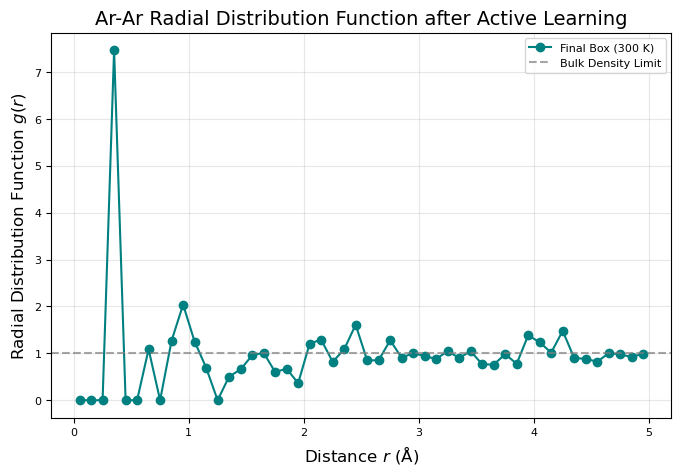

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from ase.geometry.analysis import Analysis
import ase

# 1. Define calculation parameters
# The maximum radius for an RDF is traditionally half the smallest box dimension 
# to avoid atoms interacting with their own periodic images.
box_lengths = test_atoms.get_cell_lengths_and_angles()[:3]
rmax = 5
nbins = 50

print(f"Calculating RDF up to a maximum distance of {rmax:.2f} Å...")

# 2. Initialize the ASE Analysis tool
# We pass our final atoms object inside a list to mimic a 1-frame trajectory
analyzer = Analysis([test_atoms])

# 3. Compute the RDF
# get_rdf returns a list of arrays (one for each snapshot analyzed).
# We take index [0] because we only provided one frame.
rdf = ase.geometry.rdf.get_rdf(test_atoms, rmax=rmax, nbins=nbins, elements=['Ar', 'Ar'])[0]

# 4. Construct the x-axis (distance values) for plotting
dr = rmax / nbins
# The distance value for each bin is calculated at the center of the bin
distances = np.linspace(dr/2, rmax - dr/2, nbins)

# 5. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(distances, rdf, marker='o', linestyle='-', color='teal', label='Final Box (300 K)')

# Add a horizontal line at g(r) = 1.0 (the theoretical limit for fluids at long distances)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Bulk Density Limit')

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=12)
plt.ylabel('Radial Distribution Function $g(r)$', fontsize=12)
plt.title('Ar-Ar Radial Distribution Function after Active Learning', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot in Jupyter
plt.show()

### Let's do a potential energy scan

Scanning dimer distances...


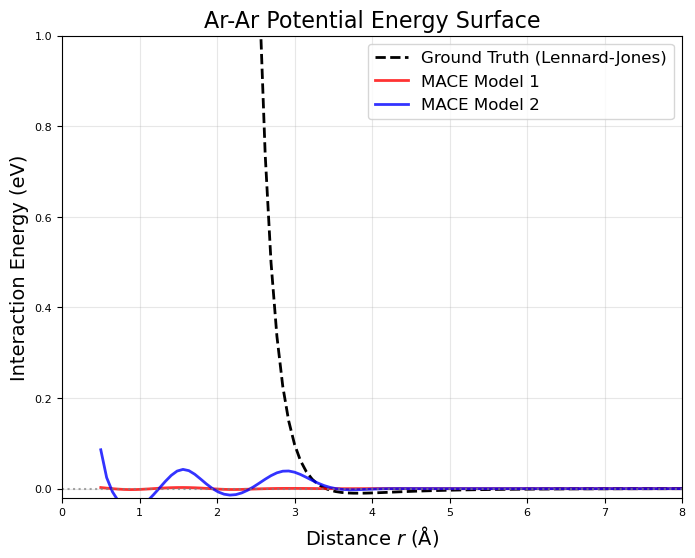

In [29]:
# 1. Initialize Calculators
# Use the ground truth LJ and your fine-tuned MACE model
lj_calc = LennardJones(epsilon=0.0103, sigma=3.40)
mace_calc_1 = MACECalculator(model_paths="mace_model_1_compiled.model", device="cpu")
mace_calc_2 = MACECalculator(model_paths="mace_model_2_compiled.model", device="cpu")

# 2. Define the scan range (5.0 Å down to 0.5 Å)
distances = np.linspace(8.0, 0.5, 100)
lj_energies = []
mace_1_energies = []
mace_2_energies = []

# Create a simple two-atom Argon system in a large empty box
dimer = Atoms('Ar2', positions=[[0, 0, 0], [8.0, 0, 0]])
dimer.set_cell([10, 10, 10])

print("Scanning dimer distances...")

# 3. Run the scan
for d in distances:
    # Move the second atom
    dimer.set_positions([[0, 0, 0], [d, 0, 0]])
    
    # Get Lennard-Jones Energy
    dimer.calc = lj_calc
    lj_energies.append(dimer.get_potential_energy())
    
    # Get MACE Energy
    dimer.calc = mace_calc_1
    mace_1_energies.append(dimer.get_potential_energy())

    # Get MACE Energy
    dimer.calc = mace_calc_2
    mace_2_energies.append(dimer.get_potential_energy())

# Convert to numpy arrays for easier math
lj_energies = np.array(lj_energies)
mace_1_energies = np.array(mace_1_energies)
mace_2_energies = np.array(mace_2_energies)

# 4. Normalize the energies
# Align both curves so that the energy at 8.0 Å (index 0) is 0.0 eV.
# This gives us the pure interaction energy.
lj_interaction = lj_energies - lj_energies[0]
mace_1_interaction = mace_1_energies - mace_1_energies[0]
mace_2_interaction = mace_2_energies - mace_2_energies[0]

# 5. Plot the Potential Energy Surface
plt.figure(figsize=(8, 6))

plt.plot(distances, lj_interaction, 'k--', linewidth=2, label='Ground Truth (Lennard-Jones)')
plt.plot(distances, mace_1_interaction, 'r-', linewidth=2, alpha=0.8, label='MACE Model 1')
plt.plot(distances, mace_2_interaction, 'b-', linewidth=2, alpha=0.8, label='MACE Model 2')

# Add a horizontal line at E = 0 for reference
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=14)
plt.ylabel('Interaction Energy (eV)', fontsize=14)
plt.title('Ar-Ar Potential Energy Surface', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# CRITICAL: The LJ repulsive wall goes to infinity. 
# We must cap the Y-axis so we can actually see the bottom of the well.
plt.ylim(-0.02, 1) 
plt.xlim(0.0, 8.0)

plt.show()

### Hmmm... wondering what is missing in the training set. Let's have a look at all the distances in the training set.

Analyzing 11 snapshots from the training set...


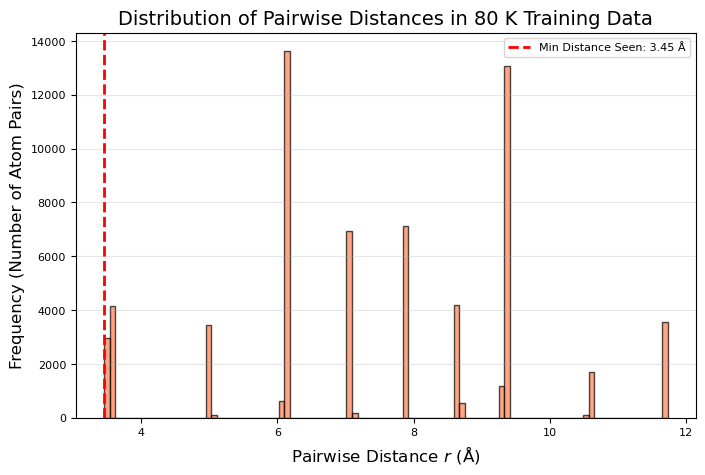

In [30]:
# 1. Load the training data 
# We load the initial 80K seed data to see what the first model learned
trajectory = read("seed_data_20K.xyz", index=":")
print(f"Analyzing {len(trajectory)} snapshots from the training set...")

all_distances = []

# 2. Extract pairwise distances from every snapshot
for atoms in trajectory:
    # Get the NxN distance matrix, applying minimum image convention (mic)
    dist_matrix = atoms.get_all_distances(mic=True)
    
    # We only want unique pairs (A->B, not B->A) and we want to ignore 
    # self-interactions (A->A, where distance = 0.0).
    # Using np.triu_indices extracts only the upper triangle of the matrix.
    # k=1 offsets the extraction to exclude the diagonal zeros.
    upper_triangle_indices = np.triu_indices_from(dist_matrix, k=1)
    unique_distances = dist_matrix[upper_triangle_indices]
    
    all_distances.extend(unique_distances)

# Convert to numpy array for easier plotting/math
all_distances = np.array(all_distances)
min_seen_dist = np.min(all_distances)

# 3. Plot the histogram
plt.figure(figsize=(8, 5))

# Use a high number of bins to see the structural peaks of the cold Argon
plt.hist(all_distances, bins=100, color='coral', edgecolor='black', alpha=0.7)

# Highlight the absolute minimum distance the model was exposed to
plt.axvline(min_seen_dist, color='red', linestyle='--', linewidth=2, 
            label=f'Min Distance Seen: {min_seen_dist:.2f} Å')

# Formatting
plt.xlabel('Pairwise Distance $r$ (Å)', fontsize=12)
plt.ylabel('Frequency (Number of Atom Pairs)', fontsize=12)
plt.title('Distribution of Pairwise Distances in 80 K Training Data', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## Phase 3: Active Learning Loop

In [ ]:
# precomputed trajectories that we can select from
possible_atoms = read("possible_configurations.xyz", index=":")

In [41]:
calc_1 = MACECalculator(model_paths="mace_model_1_compiled.model", device="cpu")
calc_2 = MACECalculator(model_paths="mace_model_2_compiled.model", device="cpu")
variations = []
found_atoms = []
for at in possible_atoms:
    # 1. Get predictions from both models
    f1 = calc_1.get_forces(at)
    f2 = calc_2.get_forces(at)
        
    # 2. Calculate uncertainty (Committee Disagreement)
    force_variance = np.mean(np.linalg.norm(f1 - f2, axis=1))
    if force_variance > 100:
        print(f"High variance configuration found! Variance = {force_variance:.2f} eV/Å")
        found_atoms.append(at)
    variations.append(force_variance)

High variance configuration found! Variance = 102.75 eV/Å
High variance configuration found! Variance = 104.79 eV/Å
High variance configuration found! Variance = 100.76 eV/Å
High variance configuration found! Variance = 104.11 eV/Å
High variance configuration found! Variance = 103.14 eV/Å
High variance configuration found! Variance = 102.19 eV/Å
High variance configuration found! Variance = 104.79 eV/Å
High variance configuration found! Variance = 101.39 eV/Å
High variance configuration found! Variance = 100.67 eV/Å
High variance configuration found! Variance = 102.20 eV/Å
High variance configuration found! Variance = 103.62 eV/Å
High variance configuration found! Variance = 104.33 eV/Å
High variance configuration found! Variance = 101.94 eV/Å
High variance configuration found! Variance = 104.42 eV/Å
High variance configuration found! Variance = 103.16 eV/Å
High variance configuration found! Variance = 105.69 eV/Å
High variance configuration found! Variance = 103.54 eV/Å
High variance 

In [59]:
import os
old_training_data = read("seed_data_20K.xyz", index=":")
extended_training_data = old_training_data + found_atoms

write("new_training_data.xyz", extended_training_data)


# Train Model 1. Using ! runs as a shell command instead
!mace_run_train \
    --name="mace_model_1" \
    --train_file="new_training_data.xyz" \
    --energy_key="energy" \
    --valid_fraction=0.01 \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="16x0e" \
    --batch_size=5 \
    --swa \
    --max_num_epochs=50 \
    --seed=43 \
    --device=cpu



/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-05-29 19:07:25.654 INFO: ===========VERIFYING SETTINGS===========
2026-05-29 19:07:25.654 INFO: MACE version: 0.3.16
2026-05-29 19:07:25.655 INFO: Using CPU
2026-05-29 19:07:25.794 INFO: ===========LOADING INPUT DATA===========
2026-05-29 19:07:25.795 INFO: Using heads: ['Default']
2026-05-29 19:07:25.795 INFO: Using the key specifications to parse data:
2026-05-29 19:07:25.795 INFO: Default: KeySpecification(info_keys={'energy': 'energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head'

In [ ]:
# Train Model 2. Using ! runs as a shell command instead
!mace_run_train \
    --name="mace_model_2" \
    --train_file="new_training_data.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --valid_fraction=0.01 \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="16x0e" \
    --batch_size=5 \
    --swa \
    --max_num_epochs=50 \
    --seed=30 \
    --device=cpu
        

def active_learning_loop(calc1, calc2, temperature):
    # Load both models for the committee
    calc_1 = MACECalculator(model_paths=calc1, device="cpu")
    calc_2 = MACECalculator(model_paths=calc2, device="cpu")

    al_atoms = bulk('Ar', crystalstructure='fcc', a=5.00, cubic=True).repeat((3, 3, 3))
    # We use calc_1 to actually drive the dynamics
    al_atoms.calc = calc_1 
    timestep = 1.0 * units.fs
    variance_threshold = 0.01 # eV/A, adjust based on your model's baseline
    new_training_data = []

    md_active_learning = Langevin(
        al_atoms,
        timestep=timestep,
        temperature_K=temperature,
        friction=0.01
    )

    # We will log the max force to watch it blow up
    for step in range(100):
        md_active_learning.run(10)
        # 1. Get predictions from both models
        f1 = calc_1.get_forces(al_atoms)
        f2 = calc_2.get_forces(al_atoms)
        
        # 2. Calculate uncertainty (Committee Disagreement)
        force_variance = np.mean(np.linalg.norm(f1 - f2, axis=1))
        
        print(f"Step {step}: Force Variance = {force_variance:.4f}")

        # 3. If variance exceeds threshold, add to training set
        if force_variance > variance_threshold: 
            print(f"  -> High uncertainty detected! Adding snapshot to training data.")
            # Extract the current snapshot as an ASE Atoms object
            snapshot = al_atoms.copy()
            snapshot.calc = truth_calc 
            new_training_data.append(snapshot)
            break
            
    print(f"Active Learning Loop Complete. {len(new_training_data)} new snapshots added to training data.")
    return new_training_data

import os
temperatures = [50, 100, 150, 200, 300, 400, 500]

for temp in temperatures:
    print(f"\nRunning active learning loop at {temp} K...")
    new_data = active_learning_loop("mace_model_1_compiled.model", "mace_model_2_compiled.model", temp)
    if os.path.exists("new_training_data.xyz"):
        old_training_data = read("new_training_data.xyz", index=":")
    else: 
        old_training_data = read("seed_data_20K.xyz", index=":")
    extended_training_data = old_training_data + new_data

    write("new_training_data.xyz", extended_training_data)


    # Train Model 1. Using ! runs as a shell command instead
    !mace_run_train \
        --name="mace_model_1" \
        --train_file="new_training_data.xyz" \
        --energy_key="energy" \
        --valid_fraction=0.01 \
        --forces_key="forces" \
        --E0s="average" \
        --model="MACE" \
        --num_interactions=2 \
        --max_ell=1 \
        --hidden_irreps="16x0e" \
        --batch_size=20 \
        --max_num_epochs=50 \
        --seed=42 \
        --device=cpu

    # Train Model 1. Using ! runs as a shell command instead
    !mace_run_train \
        --name="mace_model_2" \
        --train_file="new_training_data.xyz" \
        --energy_key="energy" \
        --forces_key="forces" \
        --valid_fraction=0.01 \
        --E0s="average" \
        --model="MACE" \
        --num_interactions=2 \
        --max_ell=1 \
        --hidden_irreps="16x0e" \
        --batch_size=20 \
        --max_num_epochs=50 \
        --seed=35 \
        --device=cpu
            

## Phase 4: Validation

Scanning dimer distances...


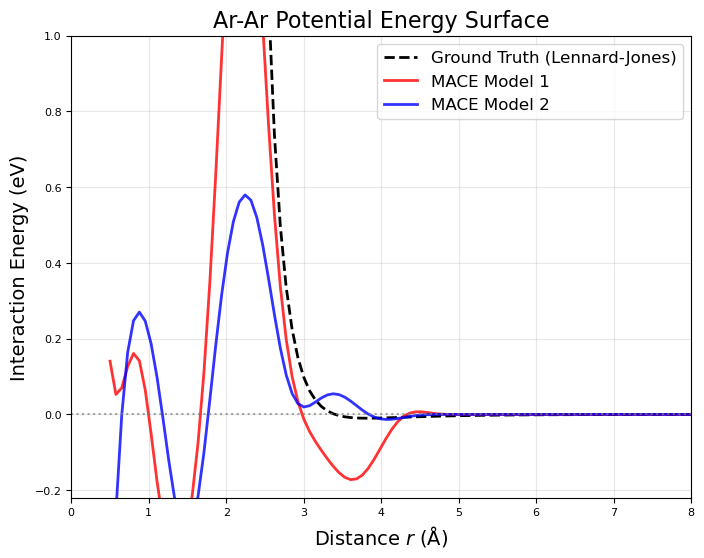

In [60]:
# 1. Initialize Calculators
# Use the ground truth LJ and your fine-tuned MACE model
lj_calc = LennardJones(epsilon=0.0103, sigma=3.40)
mace_calc_1 = MACECalculator(model_paths="mace_model_1_stagetwo_compiled.model", device="cpu")
mace_calc_2 = MACECalculator(model_paths="mace_model_2_stagetwo_compiled.model", device="cpu")

# 2. Define the scan range (5.0 Å down to 0.5 Å)
distances = np.linspace(8.0, 0.5, 100)
lj_energies = []
mace_1_energies = []
mace_2_energies = []

# Create a simple two-atom Argon system in a large empty box
dimer = Atoms('Ar2', positions=[[0, 0, 0], [8.0, 0, 0]])
dimer.set_cell([10, 10, 10])

print("Scanning dimer distances...")

# 3. Run the scan
for d in distances:
    # Move the second atom
    dimer.set_positions([[0, 0, 0], [d, 0, 0]])
    
    # Get Lennard-Jones Energy
    dimer.calc = lj_calc
    lj_energies.append(dimer.get_potential_energy())
    
    # Get MACE Energy
    dimer.calc = mace_calc_1
    mace_1_energies.append(dimer.get_potential_energy())

    # Get MACE Energy
    dimer.calc = mace_calc_2
    mace_2_energies.append(dimer.get_potential_energy())

# Convert to numpy arrays for easier math
lj_energies = np.array(lj_energies)
mace_1_energies = np.array(mace_1_energies)
mace_2_energies = np.array(mace_2_energies)

# 4. Normalize the energies
# Align both curves so that the energy at 8.0 Å (index 0) is 0.0 eV.
# This gives us the pure interaction energy.
lj_interaction = lj_energies - lj_energies[0]
mace_1_interaction = mace_1_energies - mace_1_energies[0]
mace_2_interaction = mace_2_energies - mace_2_energies[0]

# 5. Plot the Potential Energy Surface
plt.figure(figsize=(8, 6))

plt.plot(distances, lj_interaction, 'k--', linewidth=2, label='Ground Truth (Lennard-Jones)')
plt.plot(distances, mace_1_interaction, 'r-', linewidth=2, alpha=0.8, label='MACE Model 1')
plt.plot(distances, mace_2_interaction, 'b-', linewidth=2, alpha=0.8, label='MACE Model 2')

# Add a horizontal line at E = 0 for reference
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=14)
plt.ylabel('Interaction Energy (eV)', fontsize=14)
plt.title('Ar-Ar Potential Energy Surface', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# CRITICAL: The LJ repulsive wall goes to infinity. 
# We must cap the Y-axis so we can actually see the bottom of the well.
plt.ylim(-0.22, 1) 
plt.xlim(0.0, 8.0)

plt.show()

Analyzing 30 snapshots from the training set...


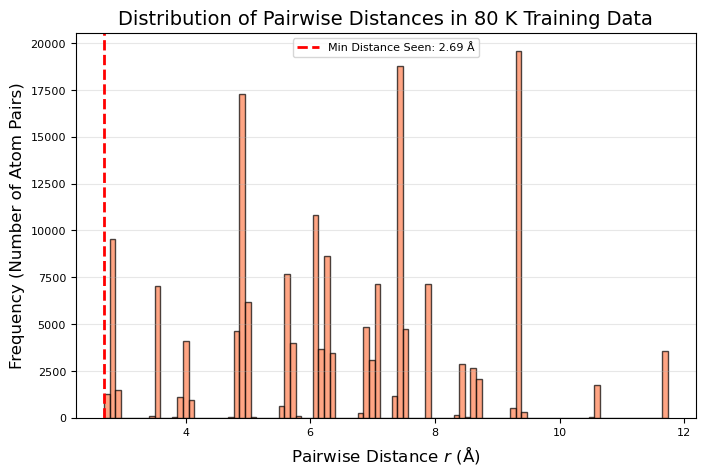

In [61]:
# 1. Load the training data 
# We load the initial 80K seed data to see what the first model learned
trajectory = read("new_training_data.xyz", index=":")
print(f"Analyzing {len(trajectory)} snapshots from the training set...")

all_distances = []

# 2. Extract pairwise distances from every snapshot
for atoms in trajectory:
    # Get the NxN distance matrix, applying minimum image convention (mic)
    dist_matrix = atoms.get_all_distances(mic=True)
    
    # We only want unique pairs (A->B, not B->A) and we want to ignore 
    # self-interactions (A->A, where distance = 0.0).
    # Using np.triu_indices extracts only the upper triangle of the matrix.
    # k=1 offsets the extraction to exclude the diagonal zeros.
    upper_triangle_indices = np.triu_indices_from(dist_matrix, k=1)
    unique_distances = dist_matrix[upper_triangle_indices]
    
    all_distances.extend(unique_distances)

# Convert to numpy array for easier plotting/math
all_distances = np.array(all_distances)
min_seen_dist = np.min(all_distances)

# 3. Plot the histogram
plt.figure(figsize=(8, 5))

# Use a high number of bins to see the structural peaks of the cold Argon
plt.hist(all_distances, bins=100, color='coral', edgecolor='black', alpha=0.7)

# Highlight the absolute minimum distance the model was exposed to
plt.axvline(min_seen_dist, color='red', linestyle='--', linewidth=2, 
            label=f'Min Distance Seen: {min_seen_dist:.2f} Å')

# Formatting
plt.xlabel('Pairwise Distance $r$ (Å)', fontsize=12)
plt.ylabel('Frequency (Number of Atom Pairs)', fontsize=12)
plt.title('Distribution of Pairwise Distances in 80 K Training Data', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()